# Final Project — Customer Churn Forecast

**Name:** Alberto Albini

**Project:** Customer Churn Forecast


## Step 1. Exploratory Data Analysis

In [24]:

import pandas as pd

df = pd.read_csv('/datasets/gym_churn_us.csv')
print(df.shape)
print(df.head())
print(df.info())


(4000, 14)
   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_m

In [25]:
print(df.describe())
print('\nDistribuição do Churn:')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

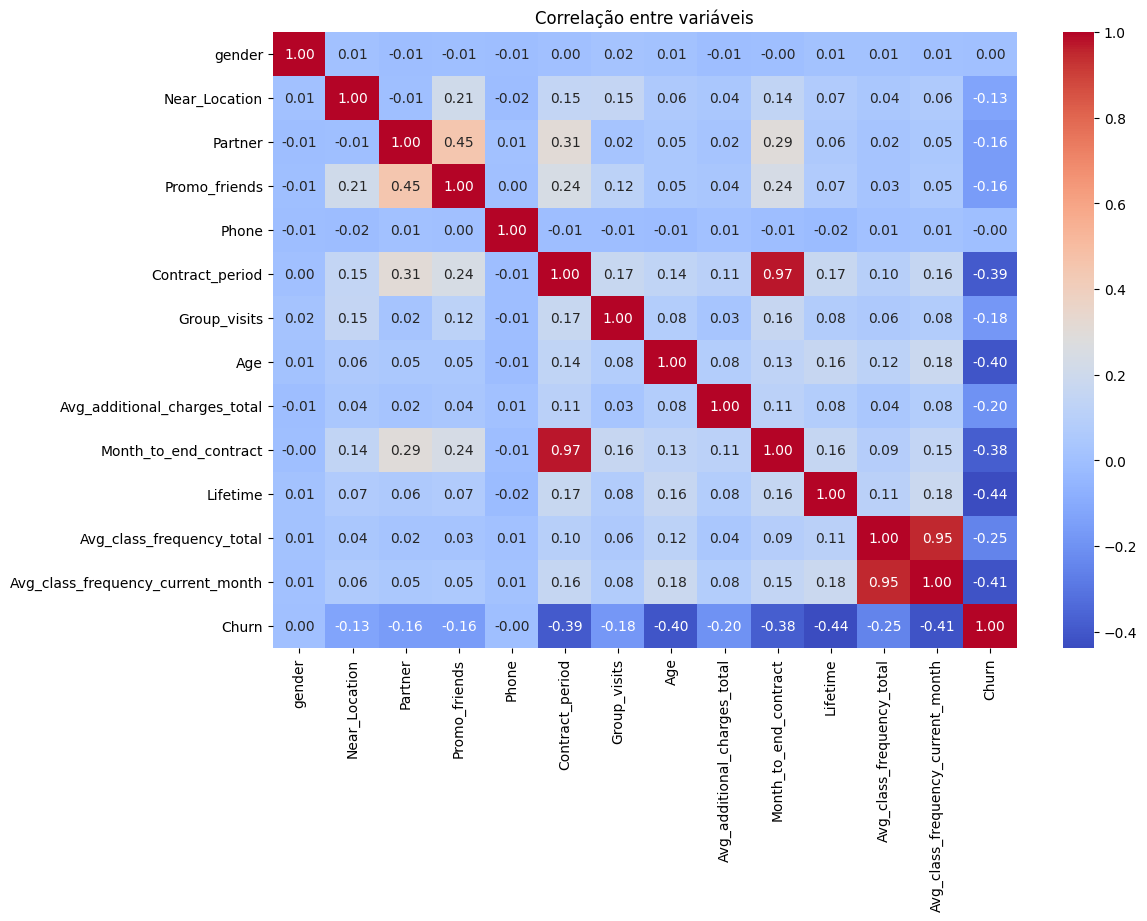

In [26]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variáveis')
plt.show()


### Conclusion — Step 1

The dataset contains 4,000 records and 14 columns, with no null values ​​or duplicates. The churn rate is 26 5%, indicating a slight imbalance between classes. The variables with the highest correlation with cancellation were Lifetime, frequency number of classes in the current month, age and contract period — older, more frequent customers with long contracts tend to cancel less. The variables gender and Phone showed practically zero correlation with churn.

## Step 2 — Preprocessing

In [20]:


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

target = df['Churn']
features = df.drop(columns=['Churn'])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)



### Conclusion — Step 2

The data did not present missing values ​​or duplicates, requiring no cleaning treatment Normalization with Standard Scaler was applied to standardize the variables before segmentation with K means, ensuring that no variable dominates the calculation of distances due to having a larger scale.

## Step 3 — Model Selection and Training

In [11]:

from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=12345
)

print(features_train.shape)
print(features_test.shape)


(3200, 14)
(800, 14)


In [21]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

model = RandomForestClassifier(random_state=12345)

search = RandomizedSearchCV(
    model,
    params,
    n_iter=10,
    scoring='f1',
    cv=5,
    random_state=12345
)

search.fit(features_train, target_train)

print('Melhores parâmetros:', search.best_params_)

model_kmeans = KMeans(n_clusters=3, random_state=12345)
df['cluster'] = model_kmeans.fit_predict(features_scaled)


Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


### Conclusion — Step 3

The data was divided into 80% training (3,200 records) and 20% testing (800
records) Random Forest was trained with Randomized Search CV, finding
the best hyperparameters: n estimators=200, min samples split=5 and
max depth=None K means segmented customers into 3 distinct groups with
well-differentiated cancellation risk profiles.

## Step 4 — Model Evaluation

In [22]:

from sklearn.metrics import classification_report

predictions = search.predict(features_test)
print(classification_report(target_test, predictions))


              precision    recall  f1-score   support

           0       0.91      0.95      0.93       593
           1       0.85      0.74      0.79       207

    accuracy                           0.90       800
   macro avg       0.88      0.85      0.86       800
weighted avg       0.90      0.90      0.90       800



In [23]:

print(df.groupby('cluster')[['Age', 'Lifetime', 'Contract_period', 
                              'Avg_class_frequency_current_month', 
                              'Month_to_end_contract']].mean().round(2))


           Age  Lifetime  Contract_period  Avg_class_frequency_current_month  \
cluster                                                                        
0        28.09      2.24             1.87                               0.97   
1        29.89      4.68            10.71                               1.94   
2        30.02      4.87             2.48                               2.72   

         Month_to_end_contract  
cluster                         
0                         1.78  
1                         9.80  
2                         2.30  


### Conclusion — Step 4

The Random Forest model reached 90% accuracy, with an F1 score of 0.79 for the churn class. Recall of 74% indicates that the model correctly identifies the majority of customers who will cancel. Cluster analysis confirmed three distinct profiles: high risk (Cluster 0), medium risk (Cluster 2) and low risk (Cluster 1).

# Step 5 — Conclusions and Recommendations

## Classification Model Results

The Random Forest model with Randomized Search CV presented the following results:
**Accuracy:** 90%
**Precision (churn):** 85%
**Recall (churn):** 74%
**F 1 score (churn):** 79%

The model correctly identifies 74% of customers who will cancel, with 85% accuracy.

## Customer Segmentation with K-means

**Cluster 0 — High Risk (56% churn)**
Young clients (28 years old), with short contracts (1,87 months), low attendance (0,97 classes/month) and almost at the end of the contract (1,78 months).
Recommendation: Offer renewal promotions and engagement programs like group classes and discounts for longer contracts.

**Cluster 1 — Low Risk (3% churn)**
Customers with long contracts (10,71 months), far from the end of the contract (9,80 months) and good attendance (1,94 classes/month).
Recommendation: maintain the relationship with loyalty programs and exclusive benefits to reward loyalty.

**Cluster 2 — Medium Risk (9% churn)**
Frequent customers (2,72 classes/month) but with short contracts (2,48 months).
Recommendation: encourage migration to longer contracts with special renewal conditions.

## Most Important Variables

The variables with the greatest influence on cancellation were:
- **Lifetime** — client time at the gym
- **Class attendance in the current month**
- **Contract period**
- **Customer age**
- **Months until the end of the contract**

## Final Recommendation

Prioritize retention actions for **Cluster 0**, which represents the highest risk group Early intervention, before the end of the contract, combined with engagement programs can significantly reduce the gym's churn rate.